#  Explorative Datenanalyse - Help Desk PerformanceNotebook for initial data exploration of the Help Desk Performance Appraisal Systems.

## 1. Setup & Imports

In [1]:
import pandas as pdimport numpy as npfrom pathlib import Pathimport matplotlib.pyplot as pltimport seaborn as sns# Visualisierungplt.style.use('seaborn-v0_8-whitegrid')sns.set_palette('husl')%matplotlib inline# PfadeDATA_DIR = Path("../data/raw")REPORTS_DIR = Path("../reports")print(" Setup abgeschlossen")

 Setup abgeschlossen

## 2. Load Data

In [2]:
print(" Lade Datensätze...")# Load all datasetsissues = pd.read_csv(DATA_DIR / "issues.csv")history = pd.read_csv(DATA_DIR / "issues_change_history.csv")snapshots = pd.read_csv(DATA_DIR / "issues_snapshot.csv")scored = pd.read_excel(DATA_DIR / "issues_snapshot_sample.xlsx")utterances = pd.read_csv(DATA_DIR / "sample_utterances.csv")# Overviewdatasets = {    'issues': issues,    'history': history,    'snapshots': snapshots,    'scored': scored,    'utterances': utterances}for name, df in datasets.items():    print(f"    {name}: {len(df):,} rows, {len(df.columns)} columns")

 Lade Datensätze...

    issues: 66,691 Zeilen, 58 Spalten    history: 257,508 Zeilen, 6 Spalten    snapshots: 90,963 Zeilen, 60 Spalten    scored: 747 Zeilen, 19 Spalten    utterances: 30,104 Zeilen, 9 Spalten

## 3. Issues Analyse

In [3]:
print(" ISSUES ANALYSE")print("="*60)print(f"\nTotal Tickets: {len(issues):,}")print(f"\ncolumns:")print(issues.columns.tolist())

 ISSUES ANALYSE============================================================Total Tickets: 66,691Spalten:['id', 'started', 'ended', 'issue_num', 'issue_proj', 'issue_reporter', 'issue_assignee', 'issue_contr_count', 'issue_type', 'issue_priority', 'issue_created', 'issue_resolution_date', 'issue_resolution', 'issue_status', 'issue_comments_count', 'last_change_date', 'wf_in_review', 'wfe_in_review', 'wf_deployment', 'wfe_deployment', 'wf_resolved', 'wfe_resolved', 'wf_open', 'wfe_open', 'wf_monitoring', 'wfe_monitoring', 'wf_done', 'wfe_done', 'wf_pending_customer_approval', 'wfe_pending_customer_approval', 'wf_rejected', 'wfe_rejected', 'wf_testing_monitoring', 'wfe_testing_monitoring', 'wf_in_progress', 'wfe_in_progress', 'wf_reopened', 'wfe_reopened', 'wf_to_do', 'wfe_to_do', 'wf_validation', 'wfe_validation', 'wf_resolved_under_monitoring', 'wfe_resolved_under_monitoring', 'wf_closed', 'wfe_closed', 'wf_waiting', 'wfe_waiting', 'wf_cancelled', 'wfe_cancelled', 'wf_under_review', 'wf

In [4]:
# Issue Typesprint("Issue Types:")issues['issue_type'].value_counts()

Issue Types:

issue_typeTicket            45275Service            5300Subtask            4746Story              4538HD Service         1686Task               1540Vacation            856Project             842Sub-task            544Epic                403Deployment          350Retrospective       241Sprint Summary      208Assistance          109Bug                  53Name: count, dtype: int64

In [5]:
# Issue Priorityprint("Issue Priority:")issues['issue_priority'].value_counts()

Issue Priority:

issue_priorityunknown    33965Medium     24788High        4554Highest     2084Blocker      656Low          560Lowest        84Name: count, dtype: int64

In [6]:
# Issue Statusprint("Issue Status:")issues['issue_status'].value_counts()

Issue Status:

issue_statusclosed                       56344done                          9714waiting                        218open                            97in_progress                     94validation                      86resolved                        59pending_deployment              47resolved_under_monitoring       18under_review                     5to_do                            3approved                         2in_review                        2cancelled                        1reopened                         1Name: count, dtype: int64

In [7]:
# Numerische Statistikennum_cols = ['wf_total_time', 'processing_steps', 'issue_comments_count']issues[num_cols].describe()

,wf_total_time,processing_steps,issue_comments_count
count,6.669100e+04,66691.000000,66691.000000
mean,6.585647e+07,3.214542,8.641796
std,9.971534e+07,2.855747,13.785747
min,0.000000e+00,0.000000,0.000000
25%,4.408454e+05,1.000000,3.000000
50%,2.961971e+06,3.000000,5.000000
75%,1.293190e+08,4.000000,10.000000
max,3.571939e+08,93.000000,685.000000


## 4. Score Analyse (Ground Truth)

In [8]:
print(" SCORE ANALYSE (Ground Truth)")print("="*60)print(f"\nBewertete Samples: {len(scored)}")print(f"Unique Assignees: {scored['assignee'].nunique()}")print(f"Unique Projekte: {scored['project'].nunique()}")

 SCORE ANALYSE (Ground Truth)============================================================Bewertete Samples: 747Unique Assignees: 103Unique Projekte: 119

In [9]:
# Score-Verteilungscore_cols = ['Q1', 'Q2', 'Q3']for q in score_cols:    valid = scored[scored[q] > 0][q]    print(f"\n{q} (nur >0):")    print(f"   N: {len(valid)}")    print(f"   Mean: {valid.mean():.2f}")    print(f"   Std: {valid.std():.2f}")

Q1 (nur >0):   N: 603   Mean: 4.12   Std: 1.32Q2 (nur >0):   N: 603   Mean: 4.10   Std: 1.33Q3 (nur >0):   N: 603   Mean: 4.14   Std: 1.32

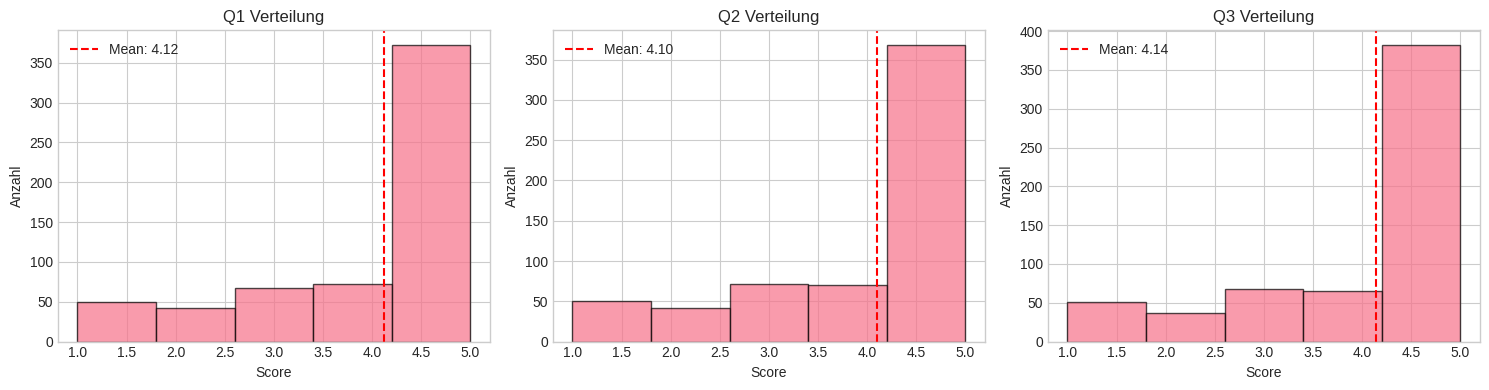

In [10]:
# Score Histogrammfig, axes = plt.subplots(1, 3, figsize=(15, 4))for i, q in enumerate(['Q1', 'Q2', 'Q3']):    valid = scored[scored[q] > 0][q]    axes[i].hist(valid, bins=5, edgecolor='black', alpha=0.7)    axes[i].set_title(f'{q} Verteilung')    axes[i].set_xlabel('Score')    axes[i].set_ylabel('Anzahl')    axes[i].axvline(valid.mean(), color='red', linestyle='--', label=f'Mean: {valid.mean():.2f}')    axes[i].legend()plt.tight_layout()plt.show()

 Score-Korrelationen:       Q1     Q2     Q3Q1  1.000  0.996  0.988Q2  0.996  1.000  0.985Q3  0.988  0.985  1.000

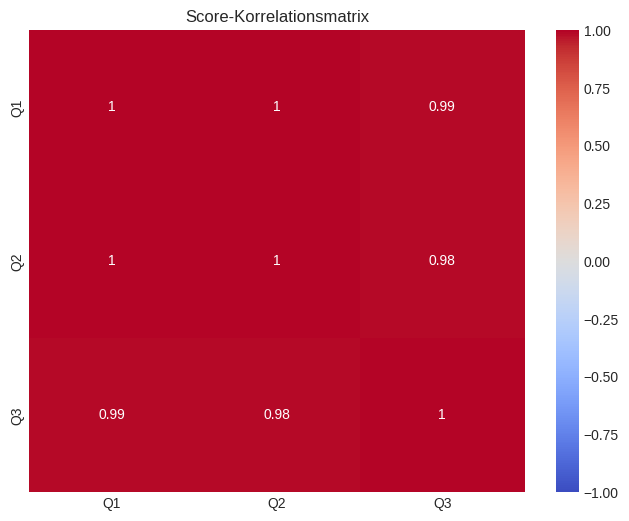

In [11]:
# Korrelationsmatrixprint(" Score-Korrelationen:")corr = scored[score_cols].corr()print(corr.round(3))# Visualisierungplt.figure(figsize=(8, 6))sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)plt.title('Score-Korrelationsmatrix')plt.show()

In [12]:
# Halo-Effekt Checkavg_corr = (corr.values.sum() - 3) / 6print(f"\nDurchschnittliche Inter-Korrelation: {avg_corr:.3f}")if avg_corr > 0.8:    print(" WARNUNG: Hohe Inter-Korrelation!")    print("   → Möglicher HALO-EFFEKT in den Bewertungen!")else:    print(" Korrelation im akzeptablen Bereich")

Durchschnittliche Inter-Korrelation: 0.990 WARNUNG: Hohe Inter-Korrelation!   → Möglicher HALO-EFFEKT in den Bewertungen!

## 5. Utterances Analyse (NLP)

In [13]:
print(" UTTERANCES ANALYSE")print("="*60)print(f"\nTotal Utterances: {len(utterances):,}")print(f"\ncolumns: {utterances.columns.tolist()}")

 UTTERANCES ANALYSE============================================================Total Utterances: 30,104Spalten: ['issueid', 'id', 'comment_seq', 'utr_seq', 'author', 'created', 'is_private', 'actionbody', 'author_role']

In [14]:
# First rowsutterances.head()

,issueid,id,comment_seq,utr_seq,author,created,is_private,actionbody,author_role
0,1004298.0,211718014.0,0,0,.wy0w13yhr,2022-01-02 11:12:51+00:00,0.0,dear ph_name team,reporter
1,1004298.0,211718014.0,0,1,.wy0w13yhr,2022-01-02 11:12:51+00:00,0.0,we need your urgent support to fix list of vul...,reporter
2,1004298.0,211718014.0,0,2,.wy0w13yhr,2022-01-02 11:12:51+00:00,0.0,please provide resolution date before end of ‘...,reporter
3,1004298.0,1045407.0,1,0,z2w_x,2022-01-02 11:13:02+00:00,1.0,.,others
4,1004298.0,1045407.0,1,1,z2w_x,2022-01-02 11:13:02+00:00,1.0,problem: .,others


In [15]:
# Author Rolesif 'author_role' in utterances.columns:    print("Author Roles:")    print(utterances['author_role'].value_counts())

Author Roles:author_roleassignee    12820others      11584reporter     5700Name: count, dtype: int64

## 6. Zusammenfassung

In [16]:
print("="*60)print(" ZUSAMMENFASSUNG")print("="*60)print(f"\n Datensätze geladen:")print(f"   - {len(issues):,} Tickets")print(f"   - {len(scored):,} bewertete Samples (Ground Truth)")print(f"   - {len(utterances):,} Utterances (NLP)")print(f"   - {scored['assignee'].nunique()} einzigartige Mitarbeiter")print(f"\n Erkannte Probleme:")print(f"   - Starker Halo-Effekt in Scores (Korr: {avg_corr:.3f})")print(f"\n Nächste Schritte:")print(f"   1. Feature Engineering")print(f"   2. ML-Modell Training")print(f"   3. Objektivitätsprüfung")

============================================================ ZUSAMMENFASSUNG============================================================ Datensätze geladen:   - 66,691 Tickets   - 747 bewertete Samples (Ground Truth)   - 30,104 Utterances (NLP)   - 103 einzigartige Mitarbeiter Erkannte Probleme:   - Starker Halo-Effekt in Scores (Korr: 0.990) Nächste Schritte:   1. Feature Engineering   2. ML-Modell Training   3. Objektivitätsprüfung